<a href="https://colab.research.google.com/github/remyaP12/labcycle_3sem/blob/main/11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.6281 - loss: 1.2115 - val_accuracy: 0.8714 - val_loss: 0.4108
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9268 - loss: 0.2563 - val_accuracy: 0.9011 - val_loss: 0.3390
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9466 - loss: 0.1660 - val_accuracy: 0.9083 - val_loss: 0.3086
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9791 - loss: 0.0808 - val_accuracy: 0.9007 - val_loss: 0.3476
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9854 - loss: 0.0636 - val_accuracy: 0.9040 - val_loss: 0.3288
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9915 - loss: 0.0395 - val_accuracy: 0.9208 - val_loss: 0.2936
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9995 - loss: 0.0111 - val_accuracy: 0.9247 - val_loss: 0.2871
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accurac

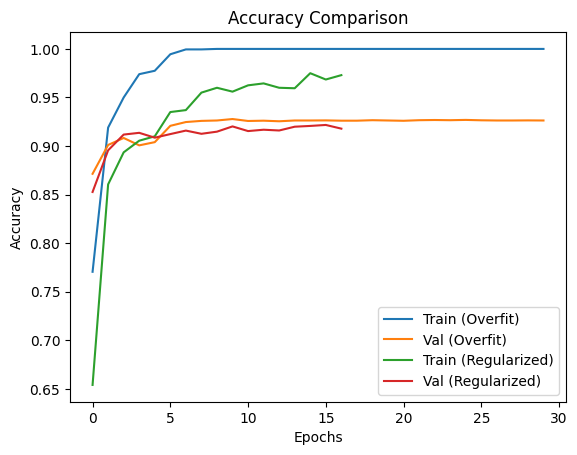

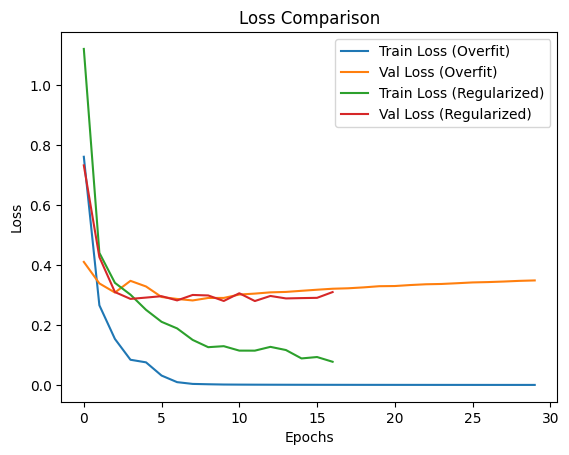

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# SMALL dataset to induce overfitting
X_train = X_train[:2000]
y_train = y_train[:2000]

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def baseline_model():
    model = Sequential([
        tf.keras.Input(shape=(28, 28)), # Add an Input layer
        Flatten(), # Remove input_shape from Flatten
        Dense(512, activation='relu'),
        Dense(512, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

history_base = baseline_model().fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_test, y_test),
    verbose=1
)

def regularized_model():
    model = Sequential([
        tf.keras.Input(shape=(28,28)),
        Flatten(),
        Dense(512),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.5),

        Dense(512),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.5),

        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_reg = regularized_model().fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

plt.figure()
plt.plot(history_base.history['accuracy'])
plt.plot(history_base.history['val_accuracy'])
plt.plot(history_reg.history['accuracy'])
plt.plot(history_reg.history['val_accuracy'])
plt.title("Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend([
    "Train (Overfit)",
    "Val (Overfit)",
    "Train (Regularized)",
    "Val (Regularized)"
])
plt.show()

plt.figure()
plt.plot(history_base.history['loss'])
plt.plot(history_base.history['val_loss'])
plt.plot(history_reg.history['loss'])
plt.plot(history_reg.history['val_loss'])
plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend([
    "Train Loss (Overfit)",
    "Val Loss (Overfit)",
    "Train Loss (Regularized)",
    "Val Loss (Regularized)"
])
plt.show()